# CFPB Complaint Classification: TF-IDF vs DistilBERT vs Claude


In [1]:
!pip -q install transformers datasets accelerate anthropic tabulate scikit-learn pandas matplotlib tqdm
import os, io, json, time, zipfile, requests, numpy as np, pandas as pd, matplotlib.pyplot as plt
from tqdm.auto import tqdm
os.makedirs("data", exist_ok=True); os.makedirs("results", exist_ok=True)
SEED = 42; N_SAMPLE = 50_000; N_TEST = 5_000; N_BERT_TRAIN = 15_000; N_LLM = 500
print("ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.7 MB/s eta 0:00:00
ready


read parquet:   0%|          | 0/2 [00:00<?, ?it/s]

rows with narrative: 415639
date range: 2015-03-19 to 2024-11-13
(50000, 4)
product
Credit reporting, credit repair services, or other personal consumer reports    20245
Debt collection                                                                  7968
Mortgage                                                                         3783
Credit reporting or other personal consumer reports                              3665
Credit card or prepaid card                                                      3086
Checking or savings account                                                      2520
Credit reporting                                                                 1673
Student loan                                                                     1619
Credit card                                                                      1364
Money transfer, virtual currency, or money service                               1220
Vehicle loan or lease                                   

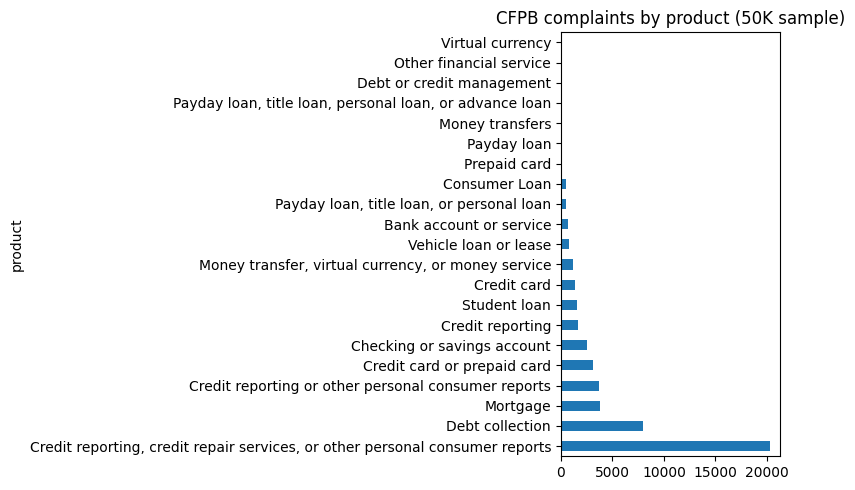

In [4]:
# Data source: CFPB complaints mirrored on Hugging Face (davidheineman/consumer-finance-complaints-large, 7.2M rows through Jan 2025). The CFPB file server blocks Colab IPs (HTTP 403), so two parquet shards are read directly.
BASE = "https://huggingface.co/datasets/davidheineman/consumer-finance-complaints-large/resolve/refs%2Fconvert%2Fparquet/default/train/"
COLS = ["complaint_what_happened", "product", "company", "date_received"]
parts = [pd.read_parquet(BASE + f, columns=COLS) for f in tqdm(["0009.parquet", "0010.parquet"], desc="read parquet")]
df = pd.concat(parts, ignore_index=True).rename(columns={"complaint_what_happened": "text", "date_received": "date"})
df = df.dropna(subset=["text", "product"]); df = df[df["text"].str.len() > 50]
print("rows with narrative:", len(df)); print("date range:", df["date"].min(), "to", df["date"].max())
df = df.sample(n=N_SAMPLE, random_state=SEED).reset_index(drop=True); df.to_csv("data/complaints_sample.csv", index=False)
print(df.shape); print(df["product"].value_counts())
ax = df["product"].value_counts().plot.barh(figsize=(8, 5)); ax.set_title("CFPB complaints by product (50K sample)"); plt.tight_layout(); plt.savefig("results/class_distribution.png", dpi=150); plt.show()

(49977, 5)
product
Credit reporting                      25583
Debt collection                        7968
Credit card or prepaid card            4566
Mortgage                               3783
Checking or savings account            3267
Student loan                           1619
Vehicle loan or lease                  1290
Money transfer or virtual currency     1287
Payday or personal loan                 614
Name: count, dtype: int64


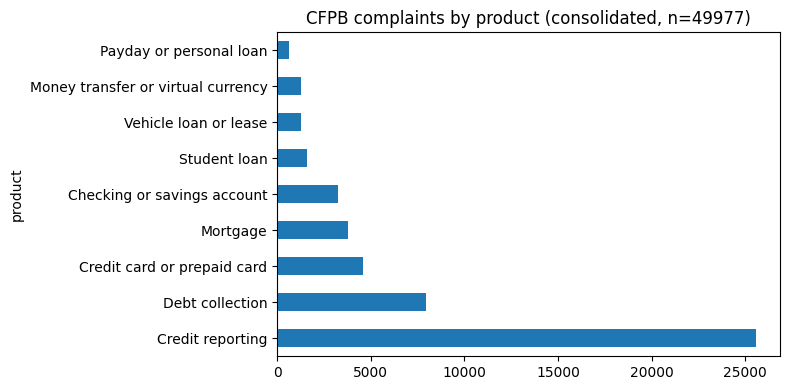

In [5]:
# CFPB renamed product categories over the years, so the raw labels contain duplicates (e.g. three flavors of credit reporting). Consolidate into 9 clean classes and drop the tiny leftovers.
CANON = {"Credit reporting, credit repair services, or other personal consumer reports": "Credit reporting", "Credit reporting or other personal consumer reports": "Credit reporting", "Credit reporting": "Credit reporting", "Debt collection": "Debt collection", "Mortgage": "Mortgage", "Credit card or prepaid card": "Credit card or prepaid card", "Credit card": "Credit card or prepaid card", "Prepaid card": "Credit card or prepaid card", "Checking or savings account": "Checking or savings account", "Bank account or service": "Checking or savings account", "Student loan": "Student loan", "Money transfer, virtual currency, or money service": "Money transfer or virtual currency", "Money transfers": "Money transfer or virtual currency", "Virtual currency": "Money transfer or virtual currency", "Vehicle loan or lease": "Vehicle loan or lease", "Consumer Loan": "Vehicle loan or lease", "Payday loan, title loan, or personal loan": "Payday or personal loan", "Payday loan, title loan, personal loan, or advance loan": "Payday or personal loan", "Payday loan": "Payday or personal loan"}
df["product_raw"] = df["product"]; df["product"] = df["product_raw"].map(CANON)
df = df.dropna(subset=["product"]).reset_index(drop=True); df.to_csv("data/complaints_sample.csv", index=False)
print(df.shape); print(df["product"].value_counts())
ax = df["product"].value_counts().plot.barh(figsize=(8, 4)); ax.set_title("CFPB complaints by product (consolidated, n=%d)" % len(df)); plt.tight_layout(); plt.savefig("results/class_distribution.png", dpi=150); plt.show()

## 1. Data: download CFPB complaints, keep narratives, sample 50K

## 2. Baseline: TF-IDF + Logistic Regression (5-fold CV) and a fixed 5K test set

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import classification_report, f1_score, accuracy_score
train, test = train_test_split(df, test_size=N_TEST, stratify=df["product"], random_state=SEED)
train.to_csv("data/train.csv", index=False); test.to_csv("data/test.csv", index=False)
pipe = make_pipeline(TfidfVectorizer(max_features=100_000, ngram_range=(1, 2), sublinear_tf=True, min_df=3),
                     LogisticRegression(max_iter=2000, C=4, class_weight="balanced"))
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
sc = cross_validate(pipe, train["text"], train["product"], cv=cv, scoring=["accuracy", "f1_macro"])
t0 = time.time(); pipe.fit(train["text"], train["product"]); fit_min = (time.time() - t0) / 60
pred = pipe.predict(test["text"])
baseline = {"cv_f1_macro": sc["test_f1_macro"].mean(), "test_f1_macro": f1_score(test["product"], pred, average="macro"),
            "test_accuracy": accuracy_score(test["product"], pred), "fit_minutes": fit_min}
json.dump(baseline, open("results/baseline.json", "w"), indent=2); print(baseline)
print(classification_report(test["product"], pred))
test = test.assign(pred_tfidf=pred)

{'cv_f1_macro': np.float64(0.7460799707770074), 'test_f1_macro': 0.748288729565775, 'test_accuracy': 0.8422, 'fit_minutes': 1.632749084631602}
                                    precision    recall  f1-score   support

       Checking or savings account       0.76      0.86      0.80       327
       Credit card or prepaid card       0.75      0.81      0.78       457
                  Credit reporting       0.94      0.87      0.90      2560
                   Debt collection       0.76      0.82      0.79       797
Money transfer or virtual currency       0.75      0.74      0.75       129
                          Mortgage       0.86      0.91      0.88       378
           Payday or personal loan       0.40      0.44      0.42        61
                      Student loan       0.81      0.90      0.85       162
             Vehicle loan or lease       0.54      0.57      0.56       129

                          accuracy                           0.84      5000
                   

## 3. Fine-tune DistilBERT (needs the GPU runtime; ~10-15 min)

In [17]:
# Fair comparison: first run used 15K rows (F1 0.721 < TF-IDF 0.748 trained on 45K). Retrain on the full training set.
bert_15k = dict(bert) if "bert" in dir() else None; N_BERT_TRAIN = len(train); print("retraining on", N_BERT_TRAIN, "rows")

retraining on 44977 rows


In [18]:
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
assert torch.cuda.is_available(), "Switch the runtime to GPU (T4) first"
MODEL = "distilbert-base-uncased"
btrain = train.sample(N_BERT_TRAIN, random_state=SEED)
labels = sorted(train["product"].unique()); l2i = {l: i for i, l in enumerate(labels)}
tok = AutoTokenizer.from_pretrained(MODEL)
def enc(b):
    out = tok(b["text"], truncation=True, max_length=256); out["labels"] = [l2i[p] for p in b["product"]]; return out
dtr = Dataset.from_pandas(btrain[["text", "product"]].reset_index(drop=True)).map(enc, batched=True)
dte = Dataset.from_pandas(test[["text", "product"]].reset_index(drop=True)).map(enc, batched=True)
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=len(labels))
args = TrainingArguments("out", per_device_train_batch_size=32, per_device_eval_batch_size=64, num_train_epochs=2,
                         learning_rate=3e-5, fp16=True, eval_strategy="epoch", save_strategy="no", report_to=[], logging_steps=100)
def metrics(p):
    y = p.predictions.argmax(-1); return {"accuracy": accuracy_score(p.label_ids, y), "f1_macro": f1_score(p.label_ids, y, average="macro")}
tr = Trainer(model=model, args=args, train_dataset=dtr, eval_dataset=dte, processing_class=tok, compute_metrics=metrics)
t0 = time.time(); tr.train(); train_min = (time.time() - t0) / 60
p = tr.predict(dte); y = p.predictions.argmax(-1)
bert = {"test_f1_macro": f1_score(p.label_ids, y, average="macro"), "test_accuracy": accuracy_score(p.label_ids, y),
        "train_minutes": train_min, "n_train": N_BERT_TRAIN}
json.dump(bert, open("results/bert.json", "w"), indent=2); print(bert)
test = test.assign(pred_bert=[labels[i] for i in y])

Map:   0%|          | 0/44977 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.470404,0.524822,0.830400,0.713852
2,0.342798,0.460047,0.856800,0.751993


{'test_f1_macro': 0.7519925478546813, 'test_accuracy': 0.8568, 'train_minutes': 9.093419981002807, 'n_train': 44977}


## 4. LLM prompting with Claude: three prompt versions on 500 test rows
**Your one manual step:** fill in one sentence per category in `DEFS` below (look at a few complaints per category). That is the prompt engineering part; leave it blank and v2 will just repeat v1.

In [9]:
DEFS = {"Credit reporting": "Errors, disputes, or identity theft issues on a credit report or with a credit bureau (Equifax, Experian, TransUnion).", "Debt collection": "A collector or agency pursuing a debt: repeated calls, threats, or a debt the consumer says is not theirs or already paid.", "Credit card or prepaid card": "Charges, fees, billing disputes, rewards, or fraud on a credit card or prepaid card.", "Mortgage": "Home loan servicing, escrow, payments, modification, foreclosure, or refinancing.", "Checking or savings account": "Deposit accounts at a bank or credit union: overdraft fees, holds, closures, unauthorized transactions.", "Student loan": "Federal or private student loan servicing, repayment plans, forgiveness, or default.", "Vehicle loan or lease": "Auto loan or lease payments, repossession, title, or dealer financing.", "Money transfer or virtual currency": "Wire transfers, peer-to-peer payment apps, remittances, or cryptocurrency transactions.", "Payday or personal loan": "Short-term payday, title, or unsecured personal loans: fees, interest, or lender behavior."}
print(len(DEFS), "definitions")

9 definitions


In [19]:
from google.colab import userdata; import anthropic, time, json
# Run 1 (naive first-in-list label parser) is kept for the README: richer prompts made the model verbose and the parser picked wrong labels.
llm_run1 = dict(llm) if "llm" in dir() and llm else {}; json.dump(llm_run1, open("results/llm_run1_naive_parser.json", "w"), indent=2)
os.environ["ANTHROPIC_API_KEY"] = "sk-ant-" + userdata.get("ANTHROPIC_API_KEY").split("sk-ant-")[-1].strip()
client = anthropic.Anthropic(max_retries=5, timeout=30.0); LLM_MODEL = "claude-haiku-4-5-20251001"
sub = test.sample(N_LLM, random_state=SEED).copy(); llm = {}; _ = [DEFS.setdefault(l, "") for l in labels]
shots = train.groupby("product").head(1).sample(min(5, len(labels)), random_state=1)
defs_txt = "\n".join(f"- {l}: {DEFS[l]}" for l in labels); shots_txt = "\n\n".join(f"Complaint: {r.text[:600]}\nCategory: {r['product']}" for _, r in shots.iterrows())
v1 = lambda t: f"Classify this consumer financial complaint into exactly one product category.\nCategories: {labels}\n\nComplaint: {t}\n\nAnswer with the category name only."
v2 = lambda t: f"Classify this consumer financial complaint into exactly one product category.\nCategory definitions:\n{defs_txt}\n\nComplaint: {t}\n\nAnswer with the category name only."
v3 = lambda t: f"Classify this consumer financial complaint into exactly one product category.\nCategories: {labels}\n\nExamples:\n{shots_txt}\n\nComplaint: {t}\n\nAnswer with the category name only."
# Parser fix: take the label that appears EARLIEST in the reply, not the first label in list order (which favored alphabetically early classes)
def parse(out): hits = [(out.lower().find(l.lower()), l) for l in labels if l.lower() in out.lower()]; return min(hits)[1] if hits else "UNPARSED"
def ask(p): r = client.messages.create(model=LLM_MODEL, max_tokens=40, messages=[{"role": "user", "content": p}]); out = r.content[0].text.strip(); time.sleep(0.4); return parse(out), r.usage.input_tokens, r.usage.output_tokens, out
for name, fn in [("v1_zero_shot", v1), ("v2_definitions", v2), ("v3_few_shot", v3)]: t0 = time.time(); res = [ask(fn(t[:2000])) for t in tqdm(sub["text"], desc=name)]; preds = [x[0] for x in res]; sub["pred_" + name] = preds; sub["raw_" + name] = [x[3] for x in res]; llm[name] = {"test_f1_macro": f1_score(sub["product"], preds, average="macro"), "test_accuracy": accuracy_score(sub["product"], preds), "input_tokens": sum(x[1] for x in res), "output_tokens": sum(x[2] for x in res), "unparsed": preds.count("UNPARSED"), "seconds": time.time() - t0}; print(name, llm[name])
json.dump(llm, open("results/llm.json", "w"), indent=2); sub.to_csv("results/test_pred_llm.csv", index=False)

v1_zero_shot:   0%|          | 0/500 [00:00<?, ?it/s]

v1_zero_shot {'test_f1_macro': 0.6851093954013818, 'test_accuracy': 0.814, 'input_tokens': 151675, 'output_tokens': 2986, 'unparsed': 1, 'seconds': 577.0090439319611}


v2_definitions:   0%|          | 0/500 [00:00<?, ?it/s]

v2_definitions {'test_f1_macro': 0.6757232537794919, 'test_accuracy': 0.822, 'input_tokens': 251675, 'output_tokens': 2971, 'unparsed': 1, 'seconds': 581.8286683559418}


v3_few_shot:   0%|          | 0/500 [00:00<?, ?it/s]

v3_few_shot {'test_f1_macro': 0.6815522915656159, 'test_accuracy': 0.822, 'input_tokens': 476175, 'output_tokens': 3004, 'unparsed': 1, 'seconds': 583.5769672393799}


## 5. Results table (paste into README)

In [20]:
PRICE_IN, PRICE_OUT = 1.00, 5.00   # USD per 1M tokens for claude-haiku-4-5
cost = lambda v: (v["input_tokens"] * PRICE_IN + v["output_tokens"] * PRICE_OUT) / 1e6 / N_LLM * 1000
rows = [["TF-IDF + LogReg (45K rows)", baseline["test_f1_macro"], baseline["test_accuracy"], f'{baseline["fit_minutes"]:.1f} min (CPU)', "~$0"]]
rows += [["DistilBERT fine-tuned (15K rows, 2 ep)", bert_15k["test_f1_macro"], bert_15k["test_accuracy"], f'{bert_15k["train_minutes"]:.0f} min (T4 GPU)', "~$0"]] if bert_15k else []
rows += [[f"DistilBERT fine-tuned ({bert['n_train']//1000}K rows, 2 ep)", bert["test_f1_macro"], bert["test_accuracy"], f'{bert["train_minutes"]:.0f} min (T4 GPU)', "~$0"]]
rows += [[f"Claude Haiku 4.5 {k} (500 rows)", v["test_f1_macro"], v["test_accuracy"], "none", f"${cost(v):.2f} per 1K"] for k, v in llm.items()]
tab = pd.DataFrame(rows, columns=["Method", "Macro-F1", "Accuracy", "Training time", "Inference cost"]).round(3)
print(tab.to_markdown(index=False)); open("results/results_table.md", "w").write(tab.to_markdown(index=False))
rows1 = [[f"Claude Haiku 4.5 {k} (naive parser, run 1)", v["test_f1_macro"], v["test_accuracy"], v["output_tokens"]] for k, v in llm_run1.items()]
tab1 = pd.DataFrame(rows1, columns=["Method", "Macro-F1", "Accuracy", "Output tokens"]).round(3); print(); print(tab1.to_markdown(index=False)); open("results/results_table_run1_naive_parser.md", "w").write(tab1.to_markdown(index=False))
test.to_csv("results/test_predictions.csv", index=False); json.dump({"baseline": baseline, "bert_15k": bert_15k, "bert_full": bert, "llm": llm, "llm_run1_naive_parser": llm_run1}, open("results/all_results.json", "w"), indent=2, default=float)

| Method                                     |   Macro-F1 |   Accuracy | Training time   | Inference cost   |
|:-------------------------------------------|-----------:|-----------:|:----------------|:-----------------|
| TF-IDF + LogReg (45K rows)                 |      0.748 |      0.842 | 1.6 min (CPU)   | ~$0              |
| DistilBERT fine-tuned (15K rows, 2 ep)     |      0.721 |      0.839 | 3 min (T4 GPU)  | ~$0              |
| DistilBERT fine-tuned (44K rows, 2 ep)     |      0.752 |      0.857 | 9 min (T4 GPU)  | ~$0              |
| Claude Haiku 4.5 v1_zero_shot (500 rows)   |      0.685 |      0.814 | none            | $0.33 per 1K     |
| Claude Haiku 4.5 v2_definitions (500 rows) |      0.676 |      0.822 | none            | $0.53 per 1K     |
| Claude Haiku 4.5 v3_few_shot (500 rows)    |      0.682 |      0.822 | none            | $0.98 per 1K     |

| Method                                                |   Macro-F1 |   Accuracy |   Output tokens |
|:---------------

## 6. Package for GitHub
Download `cfpb_nlp_results.zip` from the Files sidebar, unzip, and drag the `results/` folder plus this notebook into your GitHub repo (web upload works, no git commands needed). Then paste the table into README.md.

In [21]:
!zip -qr cfpb_nlp_results.zip results
print("done: cfpb_nlp_results.zip")

done: cfpb_nlp_results.zip
